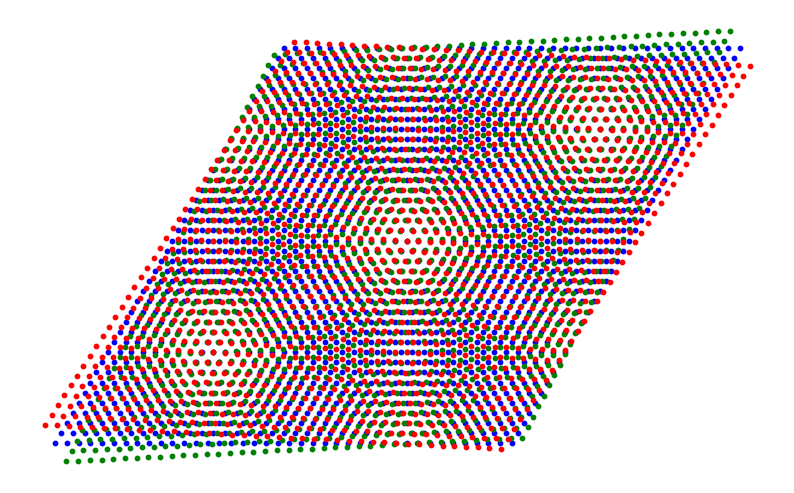

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hex_lattice(n, a=1):
    points = []
    for i in range(-n, n):
        for j in range(-n, n):
            x = a * (i + j/2)
            y = a * (np.sqrt(3)/2) * j
            points.append((x, y))
    return np.array(points)

def rotate(points, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return points @ R.T

n = 20
theta = np.radians(3)

layer1 = hex_lattice(n)
layer2 = rotate(layer1, theta)
layer3 = rotate(layer1, -theta)

plt.figure(figsize=(10,10))

plt.scatter(layer1[:,0], layer1[:,1],
            s=10, color='blue')

plt.scatter(layer2[:,0], layer2[:,1],
            s=10, color='green')

plt.scatter(layer3[:,0], layer3[:,1],
            s=10, color='red')

plt.gca().set_aspect('equal')
plt.axis('off')

plt.show()

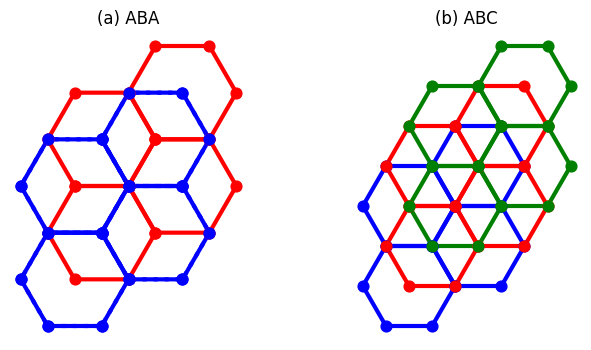

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hexagon(cx, cy, a):
    angles = np.linspace(0, 2*np.pi, 7) + np.pi/6
    x = cx + a*np.cos(angles)
    y = cy + a*np.sin(angles)
    return x,y

def graphene_layer(ax, shiftx, shifty, color, style='-'):

    a = 1
    nx = 2
    ny = 2

    for j in range(ny):
        for i in range(nx):

            cx = np.sqrt(3)*a*i + (np.sqrt(3)/2)*a*(j%2) + shiftx
            cy = 1.5*a*j + shifty

            x,y = hexagon(cx,cy,a)

            ax.plot(y,x,color=color,linewidth=3,linestyle=style)
            ax.scatter(y[:-1],x[:-1],color=color,s=60,zorder=5)

fig,ax = plt.subplots(1,2,figsize=(8,4))

a = 1

# correct graphene shifts
Bx = np.sqrt(3)/2 * a
By = 0.5 * a

Cx = np.sqrt(3) * a
Cy = 1.0 * a

# -------- ABA --------
graphene_layer(ax[0],0,0,'blue','-')     # A
graphene_layer(ax[0],Bx,By,'red','-')    # B
graphene_layer(ax[0],0,0,'blue',':')     # A (same position, dotted)

ax[0].set_title("(a) ABA")
ax[0].set_aspect('equal')
ax[0].axis('off')


# -------- ABC --------
graphene_layer(ax[1],0,0,'blue','-')     # A
graphene_layer(ax[1],Bx,By,'red','-')    # B
graphene_layer(ax[1],Cx,Cy,'green','-')  # C

ax[1].set_title("(b) ABC")
ax[1].set_aspect('equal')
ax[1].axis('off')

plt.show()